### CONTEXT

> E-commerce has become a new channel to support businesses development. Through e-commerce, businesses can get access and establish a wider market presence by providing cheaper and more efficient distribution channels for their products or services. E-commerce has also changed the way people shop and consume products and services. Many people are turning to their computers or smart devices to order goods, which can easily be delivered to their homes.

### CONTENT
> This is a sales transaction data set of UK-based e-commerce (online retail) for one year. This London-based shop has been selling gifts and homewares for adults and children through the website since 2007. Their customers come from all over the world and usually make direct purchases for themselves. There are also small businesses that buy in bulk and sell to other customers through retail outlet channels.

> The data set contains 500K rows and 8 columns. The following is the description of each column.

> - **TransactionNo (categorical)**: a six-digit unique number that defines each transaction. The letter “C” in the code indicates a cancellation.
> - **Date (numeric)**: the date when each transaction was generated.
> - **ProductNo (categorical)**: a five or six-digit unique character used to identify a specific product.
> - **Product (categorical)**: product/item name.
> - **Price (numeric)**: the price of each product per unit in pound sterling (£).
> - **Quantity (numeric)**: the quantity of each product per transaction. Negative values related to cancelled transactions.
> - **CustomerNo (categorical)**: a five-digit unique number that defines each customer.
> - **Country (categorical)**: name of the country where the customer resides.

### GOAL

> Gather useful intrinsic information by combining RFM model.

> For each segments, analyze the data, and try to answer the following questions:

> - How was the sales trend over the months?
> - What are the most frequent purchased products?
> - How many products does the customer purchase in each transaction?
> - How does each group contribute to the company's revenue?
> - What are the interval date between transactions?
> - Based on your findings, what strategy could you recommend to the business to gain more profit?
> - ***add more if necessary***

> Also, there is a small percentage of order cancellation in the data set. Most of these cancellations were due to out-of-stock conditions on some products. Under this situation, customers tend to cancel an order as they want all products delivered all at once. 

> Therefore, try to build a supervised learning model to solve this problem.

> Source from UCI Machine Learning Repository: [link to dataset](https://archive.ics.uci.edu/ml/datasets/online+retail)

### OVERVIEW

In [40]:
# import all necessary library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 

import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('online_retail.csv')

In [42]:
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E


In [43]:
# check datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  str    
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  str    
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  str    
 6   InvoiceNo    541909 non-null  str    
 7   StockCode    541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


> We can see that there are 2 features with missing values (null).

In [44]:
# check null
df.isna().sum()

Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
InvoiceNo           0
StockCode           0
dtype: int64

### PREPROCESSING

> Since many of the missing values is on the important features (CustomerID), and it's considered as an identifier that will plays an important role to the RFM models, therefore we cannot do anything to this other than dropping the values on this features.

In [45]:
# dropna
df = df.dropna()

In [46]:
# check info after dropping
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  406829 non-null  str    
 1   Quantity     406829 non-null  int64  
 2   InvoiceDate  406829 non-null  str    
 3   UnitPrice    406829 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      406829 non-null  str    
 6   InvoiceNo    406829 non-null  str    
 7   StockCode    406829 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 53.8 MB


> Since the missing values has been handled, next we will try to create a new features (TotalCost) that will play an important role on RFM for monetary value later.

> *TotalCost = Quantity x UnitPrice*.

In [47]:
# create TotalCost
df["TotalCost"] = df["Quantity"]*df["UnitPrice"]

In [48]:
# check new features
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode,TotalCost
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A,15.30
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E,20.34


> Then we will adjust the InvoiceDate format. We will create a new feature for it, so that it will fit the RFM model.

In [49]:
# create new feature and change its type
df["TransactionDate"] = pd.to_datetime(df["InvoiceDate"]).dt.date
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [50]:
# check new features
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode,TotalCost,TransactionDate
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A,15.30,2010-12-01
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053,20.34,2010-12-01
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B,22.00,2010-12-01
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G,20.34,2010-12-01
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E,20.34,2010-12-01


> We will also prepare the 'target' feature for supervised prediction later.

In [51]:
# prepare target feature, 1 : cancelled order, 0 : completed order
cancel = []
for i in df["InvoiceNo"]:
    if str(i).startswith("C"):
        cancel.append(1)
    else:
        cancel.append(0)

In [52]:
# apply target
df["cancelled"] = cancel

In [53]:
# check info
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype        
---  ------           --------------   -----        
 0   Description      406829 non-null  str          
 1   Quantity         406829 non-null  int64        
 2   InvoiceDate      406829 non-null  str          
 3   UnitPrice        406829 non-null  float64      
 4   CustomerID       406829 non-null  float64      
 5   Country          406829 non-null  str          
 6   InvoiceNo        406829 non-null  str          
 7   StockCode        406829 non-null  str          
 8   TotalCost        406829 non-null  float64      
 9   TransactionDate  406829 non-null  datetime64[s]
 10  cancelled        406829 non-null  int64        
dtypes: datetime64[s](1), float64(3), int64(2), str(5)
memory usage: 63.1 MB


> Now that we've finished the preprocess, we will copy the data and then start to build the rfm model.

In [54]:
# create copy for rfm modeling
df1 = df.copy()

### RFM MODEL BUILDING

In [55]:
now = df1['TransactionDate'].max()

In [56]:
recency = df1.groupby(by='CustomerID', as_index=False)['TransactionDate'].max()
recency.columns = ['CustomerID', 'last_trans_date']

recency['last_trans_date'] = pd.to_datetime(recency['last_trans_date'])
recency['recency'] = recency['last_trans_date'].apply(lambda x: (now-x).days)

In [57]:
recency.head()

,CustomerID,last_trans_date,recency
0,12346.0,2011-01-18,325
1,12347.0,2011-12-07,2
2,12348.0,2011-09-25,75
3,12349.0,2011-11-21,18
4,12350.0,2011-02-02,310


In [58]:
frequency = pd.DataFrame()
frequency = df['CustomerID'].value_counts().reset_index().rename(columns={'count':'frequency'})

In [59]:
frequency.head()

,CustomerID,frequency
0,17841.0,7983
1,14911.0,5903
2,14096.0,5128
3,12748.0,4642
4,14606.0,2782


In [60]:
monetary = df.groupby(by='CustomerID', as_index=False).agg({'TotalCost':'sum'})
monetary.columns = ['CustomerID','monetary']

In [61]:
monetary.head()

,CustomerID,monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [62]:
# create rfm table
rf = pd.merge(recency, frequency, on = "CustomerID")
rfm = pd.merge(rf, monetary, on = "CustomerID")


In [63]:
# split rfm quantiles 
quantiles = rfm.quantile(q=[0.25,0.5,0.75])
quantiles


,CustomerID,last_trans_date,recency,frequency,monetary
0.25,13812.75,2011-07-19,16.0,17.0,293.3625
0.50,15300.50,2011-10-20,50.0,42.0,648.0750
0.75,16778.25,2011-11-23,143.0,102.0,1611.7250


In [64]:
# function to get quantiles score
# arguments : (x = value, p = recency, monetary_value, frequency, k = quartiles dict)

def RScore(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4
    
def FMScore(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1


In [65]:
# rfm segmentation score
rfm['R_Quartile'] = rfm['recency'].apply(RScore, args=('recency',quantiles))
rfm['F_Quartile'] = rfm['frequency'].apply(FMScore, args=('frequency',quantiles))
rfm['M_Quartile'] = rfm['monetary'].apply(FMScore, args=('monetary',quantiles))


In [66]:
# calculate rfm score
rfm['RFMScore'] =  rfm["R_Quartile"].map(str) + rfm["F_Quartile"].map(str) + rfm["M_Quartile"].map(str)


In [67]:
segname = []

for r, f, m in zip(rfm["R_Quartile"], rfm["F_Quartile"], rfm["M_Quartile"]):

    # Best Customers
    if r == 1 and f == 1 and m == 1:
        segname.append("Best Customers")

    # Loyal Customers
    elif f == 1:
        segname.append("Loyal Customers")

    # Potential Customers
    elif r == 1 or r == 2:
        segname.append("Potential Customers")

    # At Risk Customers
    elif r == 3:
        segname.append("At Risk Customers")

    # Lost Customers
    else:
        segname.append("Lost Customers")

rfm["segment"] = segname

In [68]:
rfm.head()

,CustomerID,last_trans_date,recency,frequency,monetary,R_Quartile,F_Quartile,M_Quartile,RFMScore,segment
0,12346.0,2011-01-18,325,2,0.00,4,4,4,444,Lost Customers
1,12347.0,2011-12-07,2,182,4310.00,1,1,1,111,Best Customers
2,12348.0,2011-09-25,75,31,1797.24,3,3,1,331,At Risk Customers
3,12349.0,2011-11-21,18,73,1757.55,2,2,1,221,Potential Customers
4,12350.0,2011-02-02,310,17,334.40,4,4,3,443,Lost Customers


In [70]:
# jumlah masing2 segment
cnt_seg = rfm.groupby("segment", as_index=False)["CustomerID"].nunique().sort_values(by = "CustomerID", ascending=False).reset_index()
# tambahkan kolom percentage
cnt_seg["pct"] = round(cnt_seg["CustomerID"]/sum(cnt_seg["CustomerID"]) *100, 1)


In [71]:
cnt_seg.head()

,index,segment,CustomerID,pct
0,4,Potential Customers,1337,30.6
1,2,Lost Customers,1040,23.8
2,0,At Risk Customers,914,20.9
3,3,Loyal Customers,623,14.2
4,1,Best Customers,458,10.5


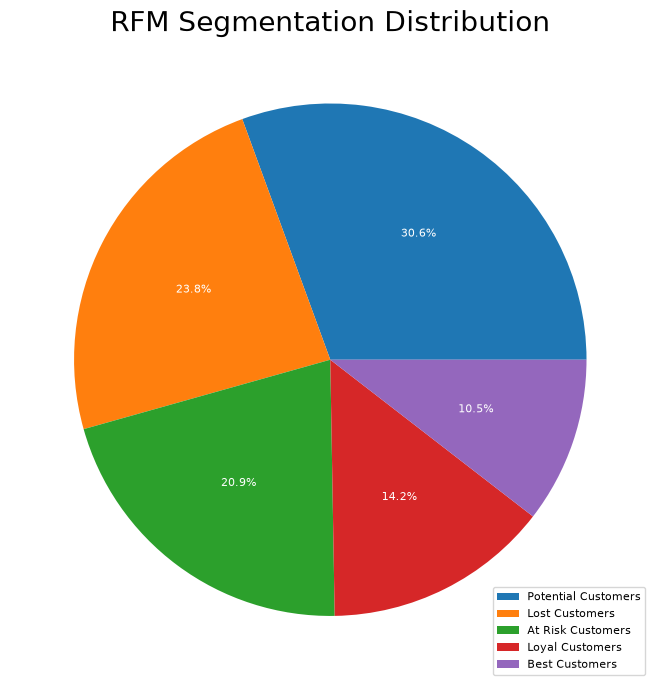

In [72]:
# visualisasi hasil
plt.figure(figsize=(7,7))
plt.pie(cnt_seg["CustomerID"], 
        autopct = '%.1f%%', 
        textprops = {'fontsize' : 8, 
                     'color' : 'white'})
plt.title("RFM Segmentation Distribution", fontsize=20)
plt.legend(cnt_seg["segment"], loc='lower right', prop={'size': 7.7})
plt.tight_layout()
plt.show()


- Based on the plot above, 30.6% customers are classified as potential customer, 23.8% customers are classified as lost customer, 20.9% customers are at risk customer, 14.2% are loyal customer and 10.5% customers are classified as best customer.

### EXPLORATORY DATA ANALYSIS



In [73]:
res = pd.merge(df1, rfm, on = 'CustomerID')

In [74]:
res.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceNo,StockCode,TotalCost,TransactionDate,cancelled,last_trans_date,recency,frequency,monetary,R_Quartile,F_Quartile,M_Quartile,RFMScore,segment
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,536365,85123A,15.30,2010-12-01,0,2011-02-10,302,312,5288.63,4,1,1,411,Loyal Customers
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,71053,20.34,2010-12-01,0,2011-02-10,302,312,5288.63,4,1,1,411,Loyal Customers
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,536365,84406B,22.00,2010-12-01,0,2011-02-10,302,312,5288.63,4,1,1,411,Loyal Customers
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029G,20.34,2010-12-01,0,2011-02-10,302,312,5288.63,4,1,1,411,Loyal Customers
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,536365,84029E,20.34,2010-12-01,0,2011-02-10,302,312,5288.63,4,1,1,411,Loyal Customers


### How was the sales trend over the months?

In [75]:
res['month'] = pd.DatetimeIndex(res['TransactionDate']).month

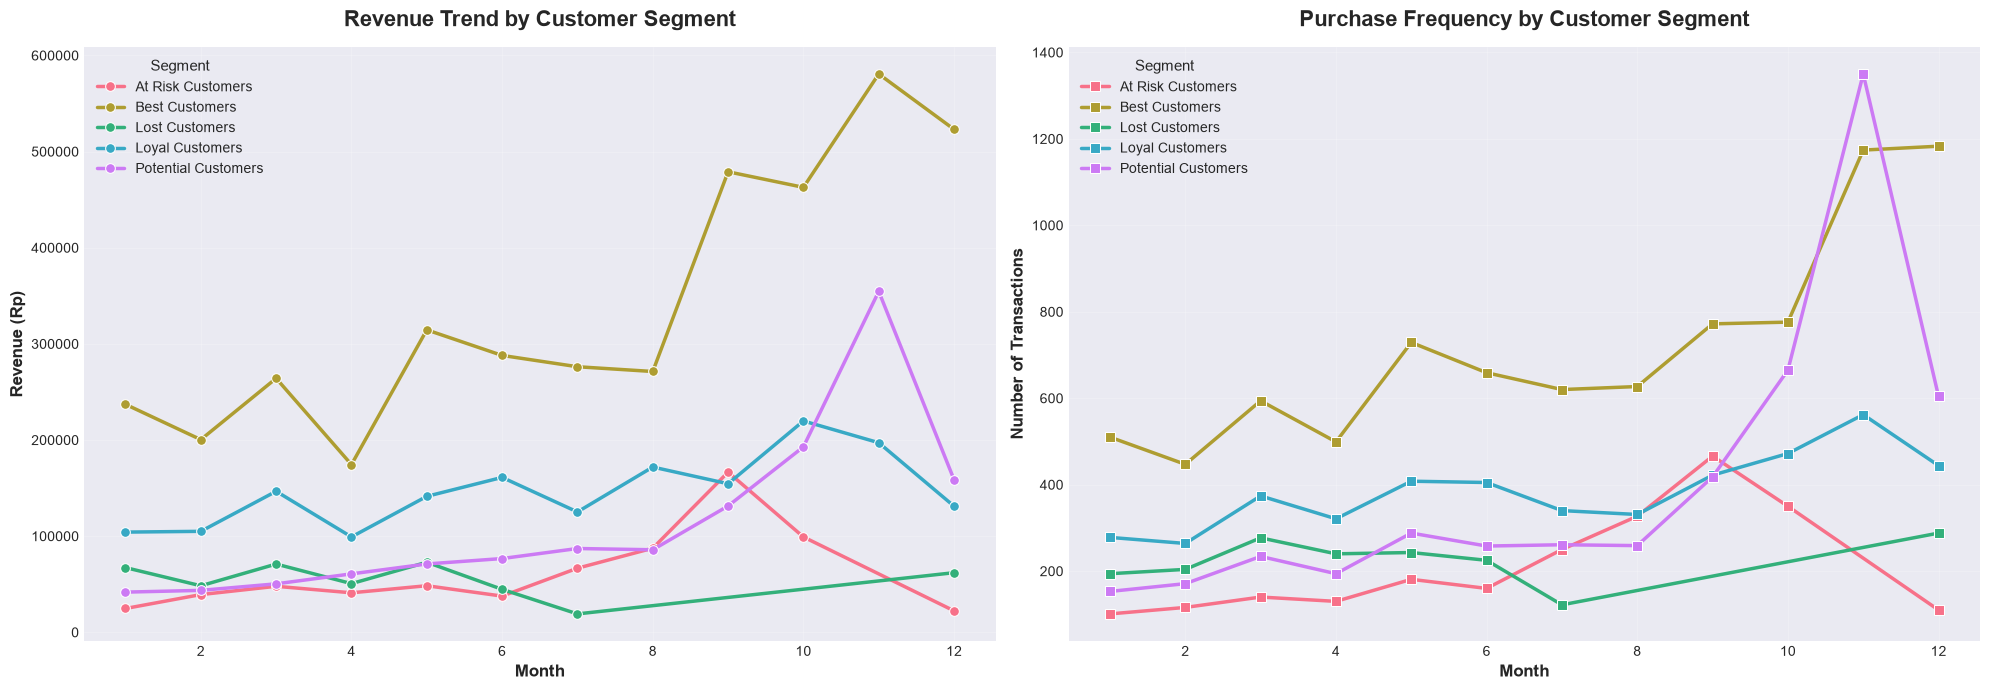

In [76]:
# Siapkan data
revenue_data = res.groupby(by=['month', 'segment'])['TotalCost'].sum().reset_index()
frequency_data = res.groupby(by=['month', 'segment'])['InvoiceNo'].nunique().reset_index()

# ===== VERSI 1: Dua subplot berdampingan dengan styling profesional =====
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

palette = 'husl'  # Palet warna yang lebih kontras

# Revenue
sns.lineplot(
    data=revenue_data, x='month', y='TotalCost', hue='segment',
    palette=palette, marker='o', linewidth=2.5, markersize=7,
    ax=axes[0], legend=True
)
axes[0].set_title('Revenue Trend by Customer Segment', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (Rp)', fontsize=12, fontweight='bold')
axes[0].legend(title='Segment', fontsize=10, title_fontsize=11, loc='best')
axes[0].grid(True, alpha=0.2)

# Frequency
sns.lineplot(
    data=frequency_data, x='month', y='InvoiceNo', hue='segment',
    palette=palette, marker='s', linewidth=2.5, markersize=7,
    ax=axes[1], legend=True
)
axes[1].set_title('Purchase Frequency by Customer Segment', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Month', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[1].legend(title='Segment', fontsize=10, title_fontsize=11, loc='best')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

- Based on the plot above best customers made the biggest revenue compare to other segmented customer.
- The highest Spike of revenue and frequency buying happened in september and it happended in all over segemented.
- The lowest downfall of revenue and frequency buying happened in december and also it happened in all over segemented.

### What are the most frequent purchased products?

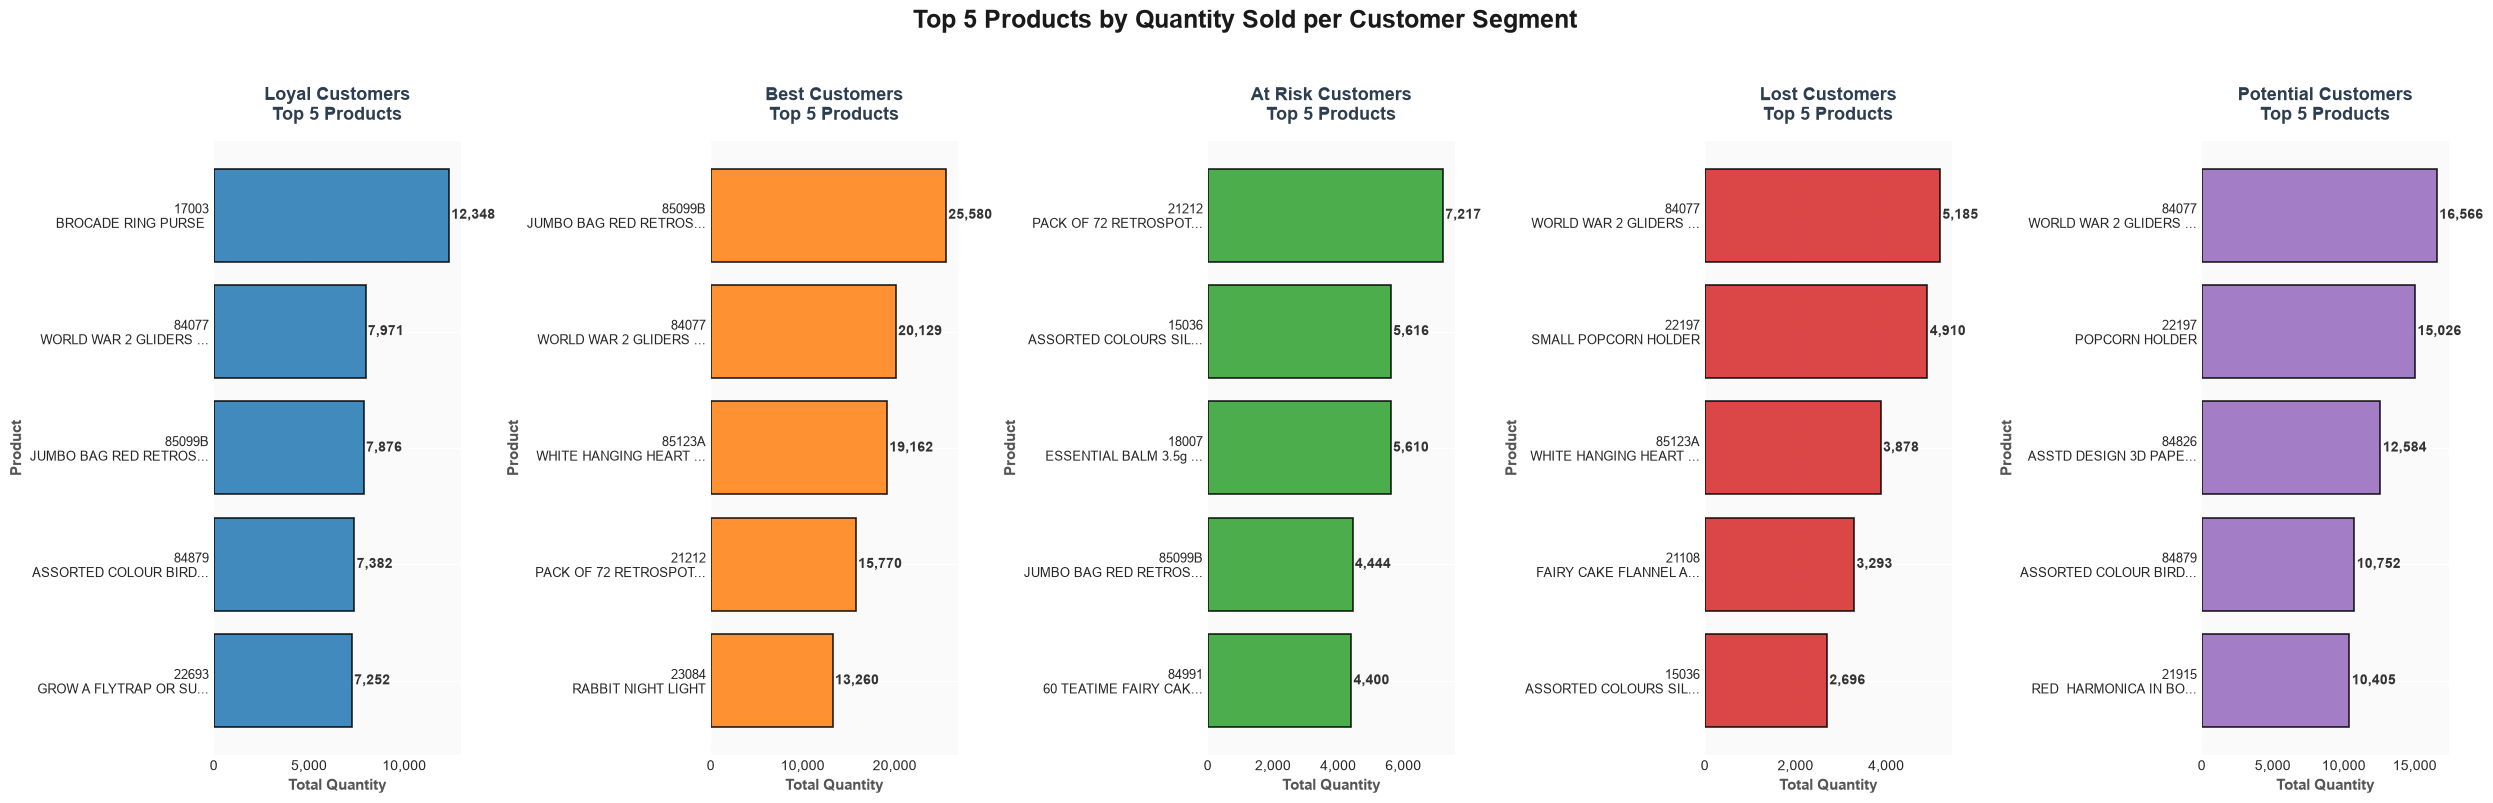

In [77]:
import matplotlib.ticker as ticker

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(25, 8))

segments = res['segment'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Pastikan tidak lebih dari 5 segment
segments = segments[:5]

for i, segment in enumerate(segments):
    ax = axs[i]
    
    # Ambil top 5 produk per segment (yang terbesar)
    data = (res[res['segment'] == segment]
            .groupby(['StockCode', 'Description'])['Quantity']
            .sum()
            .sort_values(ascending=False)  # Descending untuk top 5 terbesar
            .head(5)  # Ambil 5 teratas
            .reset_index())
    
    # Reverse agar yang terbesar di atas
    data = data.iloc[::-1].reset_index(drop=True)
    
    # Buat label kombinasi yang lebih informatif
    labels = [f"{code}\n{desc[:20]}..." if len(desc) > 20 else f"{code}\n{desc}" 
              for code, desc in zip(data['StockCode'], data['Description'])]
    
    # Create horizontal bar chart
    bars = ax.barh(range(len(data)), data['Quantity'], 
                   color=colors[i % len(colors)], 
                   alpha=0.85, 
                   edgecolor='black', 
                   linewidth=1.2)
    
    # Add value labels di sebelah kanan bar
    for idx, (bar, value) in enumerate(zip(bars, data['Quantity'])):
        width = bar.get_width()
        ax.text(width + max(data['Quantity'])*0.01, 
                idx,
                f'{int(value):,}',
                ha='left', 
                va='center', 
                fontsize=10, 
                fontweight='bold',
                color='#333333')
    
    # Styling
    ax.set_title(f'{segment}\nTop 5 Products', 
                 fontsize=13, 
                 fontweight='bold', 
                 pad=15,
                 color='#2c3e50')
    ax.set_xlabel('Total Quantity', 
                  fontsize=11, 
                  fontweight='bold',
                  color='#555555')
    ax.set_ylabel('Product', 
                  fontsize=11, 
                  fontweight='bold',
                  color='#555555')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(labels, fontsize=9, ha='right')
    
    # Grid horizontal
    ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Format x-axis dengan comma separator
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Background dan spines
    ax.set_facecolor('#fafafa')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Adjust layout untuk y-label
    ax.tick_params(axis='y', length=0)

# Overall title
plt.suptitle('Top 5 Products by Quantity Sold per Customer Segment', 
             fontsize=18, 
             fontweight='bold', 
             y=0.998,
             color='#1a1a1a')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- The best seller product sold in lost customers and potential customers segment was world war 2 glides.
- otherwise the best seller product sold in other 3 segment was different with each other.
- in loyal customers the best seller product was brocade ring purse.
- in best customers the best seller product was jumbo bag red.
- in at risk segmet the best seller product was pack of 72 retrospot.

### How many products does the customer purchase in each transaction?

In [78]:
res_purc = res.groupby(by=['segment'])['Quantity'].mean().reset_index()

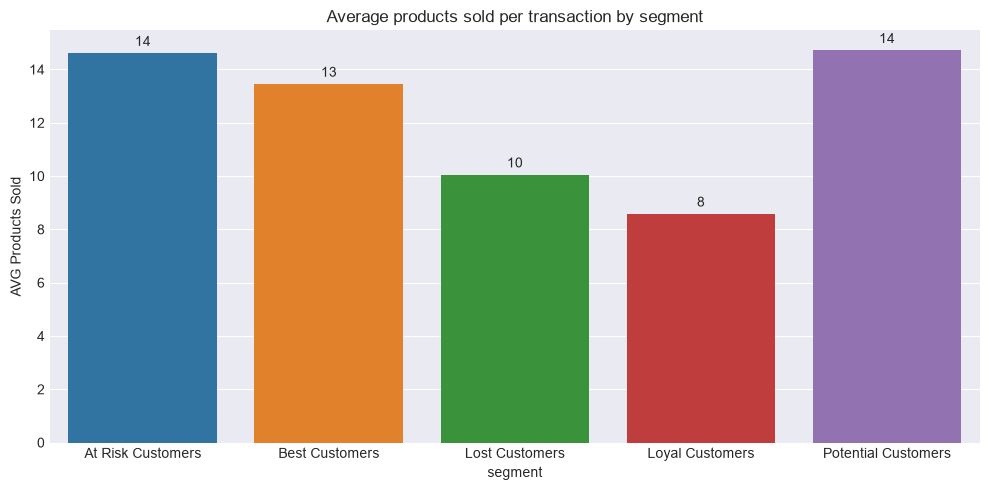

In [79]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=res_purc, y='Quantity', x='segment', palette='tab10')

# Menambahkan label nilai di atas setiap bar
for i, container in enumerate(ax.containers):
    ax.bar_label(container, fmt='%d', padding=3)

plt.ylabel('AVG Products Sold')
plt.title('Average products sold per transaction by segment')
plt.tight_layout()
plt.show()

- Based on the graph above, potential customers and at-risk customers show the highest average number of products sold per transaction, namely 14 products sold per transaction.
- The lowest average product sold per transaction was loyal customer, namely 8 products sold per transcation.

### How does each group contribute to the company's revenue?

In [80]:
z = res.groupby(by='segment')['TotalCost'].sum().reset_index()

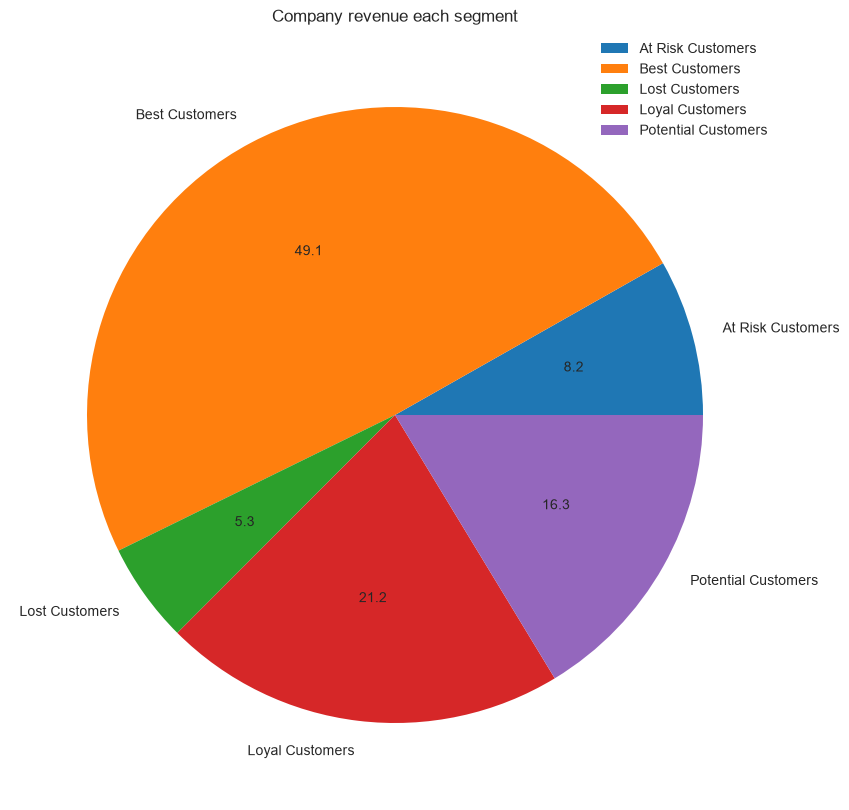

In [81]:
plt.figure(figsize=(10,10))
plt.pie(data=z, x='TotalCost', labels='segment', autopct='%.1f')
plt.title('Company revenue each segment')
plt.legend()
plt.show()

- Based on the plot above the biggest revenue was produced by best customer segment, namely 49.1%
- Otherwise the smallest revenue was produced by lost customer segement, namely 49.1%

### What are the interval date between transactions?

In [84]:
res_interval = res.groupby(by='InvoiceNo')[['CustomerID', 'TransactionDate','segment']].first().reset_index()

res_interval = res_interval.sort_values(by=['CustomerID', 'TransactionDate'])

# 3. Hitung selisih waktu antara transaksi saat ini dengan transaksi sebelumnya untuk setiap Customer
# groupby('CustomerID') memastikan kita hanya membandingkan transaksi dalam satu customer
# .diff() menghitung selisih baris saat ini dengan baris sebelumnya dalam grup yang sama
res_interval['DaysSinceLastPurchase'] = res_interval.groupby('CustomerID')['TransactionDate'].diff().dt.days

res_interval['DaysSinceLastPurchase'] = res_interval['DaysSinceLastPurchase'].fillna(0)
res_interval = res_interval.sort_values(by='TransactionDate')

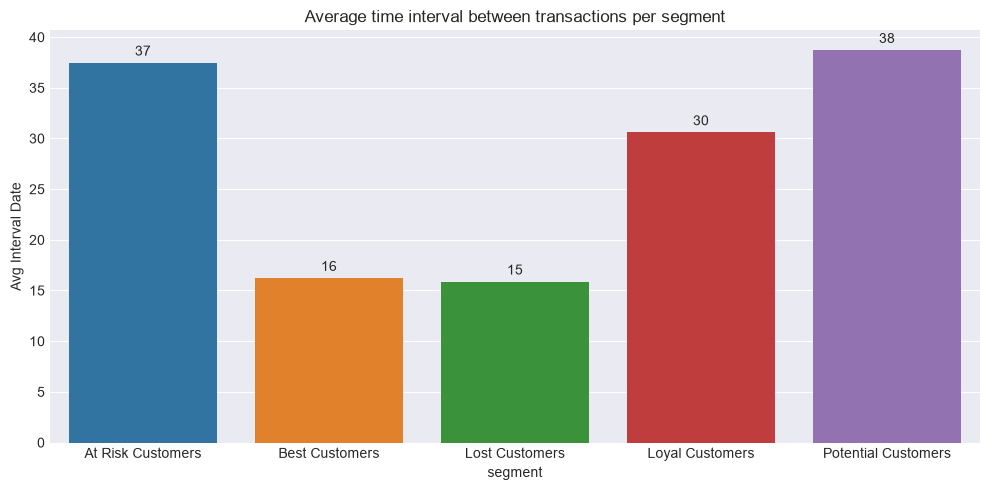

In [87]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=res_interval.groupby(by='segment')['DaysSinceLastPurchase'].mean().reset_index(), y='DaysSinceLastPurchase', x='segment', palette='tab10')

# Menambahkan label nilai di atas setiap bar
for i, container in enumerate(ax.containers):
    ax.bar_label(container, fmt='%d', padding=3)

plt.ylabel('Avg Interval Date')
plt.title('Average time interval between transactions per segment')
plt.tight_layout()
plt.show()

- Based on the plot above the shortest average time interval between transaction was showed by lost customer namely 15 days after last transaction.
- Otherwise the longest average time interval between transaction was showed by potential customer namely 38 days after last transaction.

### Conclusion

- **Segment summary**
    - Potential: 30.6% of customers — the largest segment.
    - Lost: 23.8%, At Risk: 20.9%, Loyal: 14.2%, Best: 10.5%.

- **Revenue contribution**
    - Best customers account for the largest share (≈49.1%) — focusing on their retention is crucial.
    - Lost customers contribute the least.

- **Sales trends**
    - Revenue and frequency peaks occur around September.
    - A significant decline is observed in December.

- **Best selling products**
    - Top products vary by segment; specific items (e.g., World War 2 gliders, brocade ring purse, jumbo bag red, pack of 72 retrospot) stand out in certain segments. leverage this for segment-specific offers.

- **Purchasing habits**
    - Average items per transaction are highest for Potential and At-Risk segments (~14) and lowest for Loyal customers (~8).

- **Inter-transaction interval**
    - Lost customers have the shortest interval (~15 days); Potential customers have the longest (~38 days).

- **Brief implications & recommendations**
    - Retention: Prioritize loyalty programs and cross-selling for Best and Loyal customers.
    - Reactivation: Run re-engagement campaigns and special offers for Potential and Lost customers.
    - Prevent churn: Identify At-Risk customers for personalized promotions or limited-time offers.
    - Products & stock: Focus stock management on top-performing products per segment to reduce cancellations.
    - Campaign timing: Leverage seasonal insights (e.g., the September peak) for major promotions.
    - Conclusion: RFM segmentation provides a clear roadmap for action — combining high-value customer retention, reactivation of large segments (Potential/Lost), and product/stock optimization will boost revenue and reduce cancellations.